In [14]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [15]:
df = pd.read_csv(r"C:\Users\mohit\OneDrive\Desktop\UAC_Forecasting\HHS_Unaccompanied_Alien_Children_Program.csv")

In [16]:
print(df.shape)

(1170, 6)


In [17]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [18]:
df.tail()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
1165,NaN,NaN,NaN,NaN,NaN,NaN
1166,NaN,NaN,NaN,NaN,NaN,NaN
1167,NaN,NaN,NaN,NaN,NaN,NaN
1168,NaN,NaN,NaN,NaN,NaN,NaN
1169,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


In [20]:
df.describe(include='all')

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
count,720,720.000000,720.000000,720.000000,720,720.000000
unique,720,NaN,NaN,NaN,642,NaN
top,"December 21, 2025",NaN,NaN,NaN,"5,963",NaN
freq,1,NaN,NaN,NaN,3,NaN
mean,NaN,93.523611,171.494444,128.668056,NaN,173.406944
std,NaN,72.646625,126.354965,97.322012,NaN,125.702841
min,NaN,0.000000,7.000000,0.000000,NaN,0.000000
25%,NaN,12.000000,36.000000,14.000000,NaN,19.750000
50%,NaN,99.000000,193.000000,157.000000,NaN,181.000000
75%,NaN,147.250000,263.250000,199.250000,NaN,267.000000


In [21]:
print(df.columns)

Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='object')


In [22]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 449


In [23]:
df.isnull().sum()

Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64

In [24]:
df.dtypes

Date                                                object
Children apprehended and placed in CBP custody*    float64
Children in CBP custody                            float64
Children transferred out of CBP custody            float64
Children in HHS Care                                object
Children discharged from HHS Care                  float64
dtype: object

In [25]:
df[df.isnull().all(axis=1)].head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
720,NaN,NaN,NaN,NaN,NaN,NaN
721,NaN,NaN,NaN,NaN,NaN,NaN
722,NaN,NaN,NaN,NaN,NaN,NaN
723,NaN,NaN,NaN,NaN,NaN,NaN
724,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
df = df.dropna(how='all').reset_index(drop=True)

In [27]:
print(df.shape)
df.info()

(720, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 33.9+ KB


In [29]:
df.columns = (
    df.columns
      .str.strip()
      .str.replace('*', '', regex=False)
)

In [31]:
df['Date'] = pd.to_datetime(df['Date'])

In [34]:
df['Children in HHS Care'] = (
    df['Children in HHS Care']
      .astype(str)
      .str.replace(',', '', regex=False)
      .str.strip()
)

df['Children in HHS Care'] = pd.to_numeric(
    df['Children in HHS Care'],
    errors='coerce'
)

In [38]:
df.set_index("Date", inplace=True)

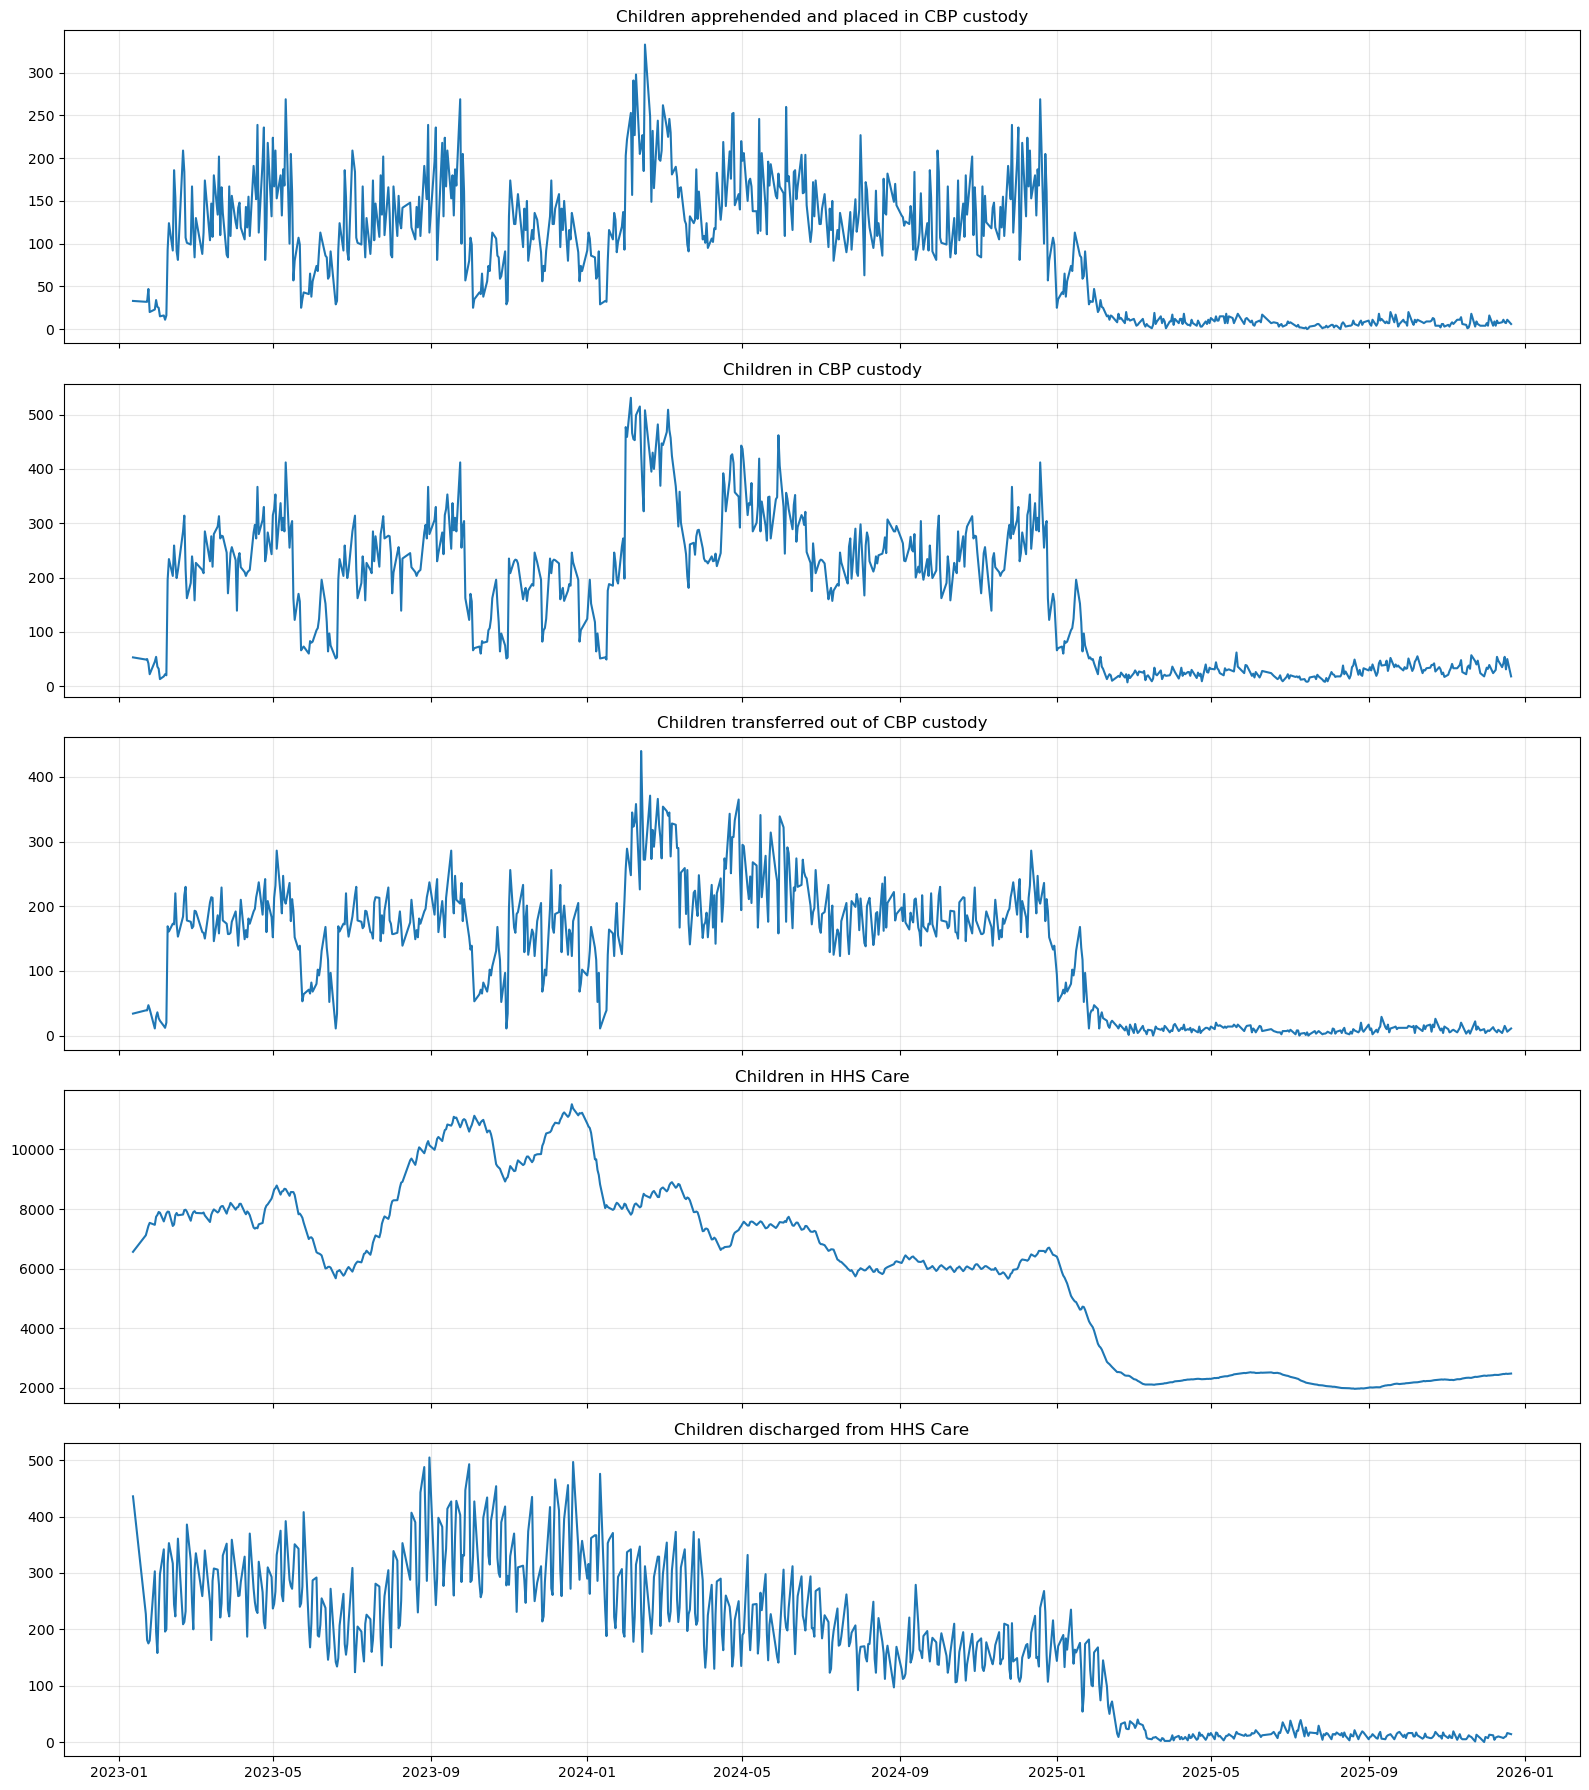

In [39]:
fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True)

columns = df.columns

for ax, col in zip(axes, columns):
    ax.plot(df.index, df[col], linewidth=1.5)
    ax.set_title(col)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

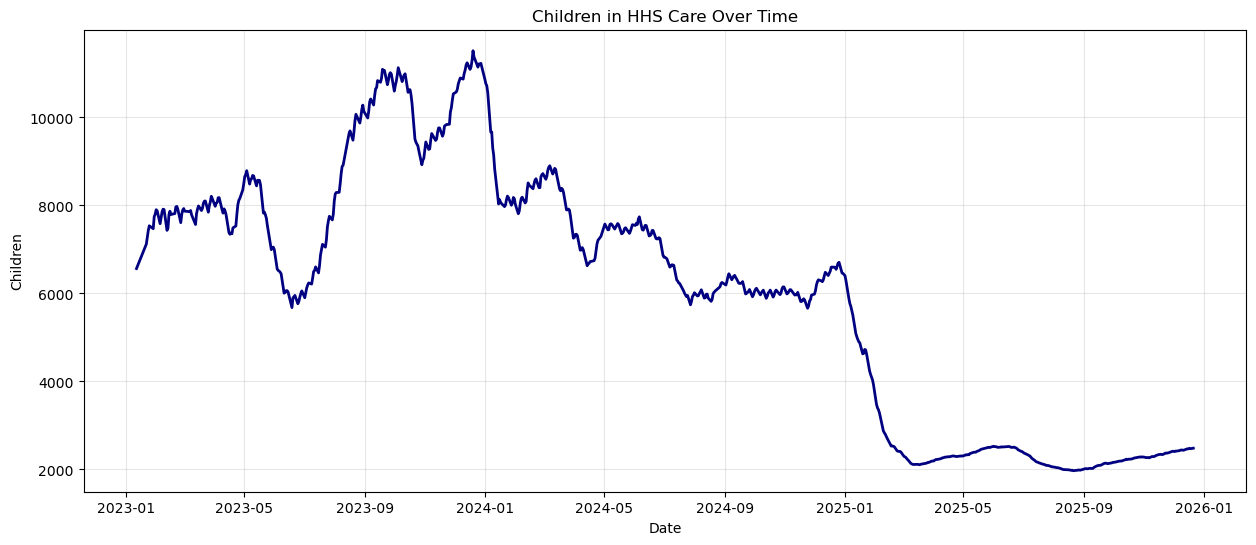

In [40]:
plt.figure(figsize=(15,6))

plt.plot(
    df.index,
    df['Children in HHS Care'],
    color='navy',
    linewidth=2
)

plt.title("Children in HHS Care Over Time")
plt.xlabel("Date")
plt.ylabel("Children")

plt.grid(alpha=0.3)

plt.show()

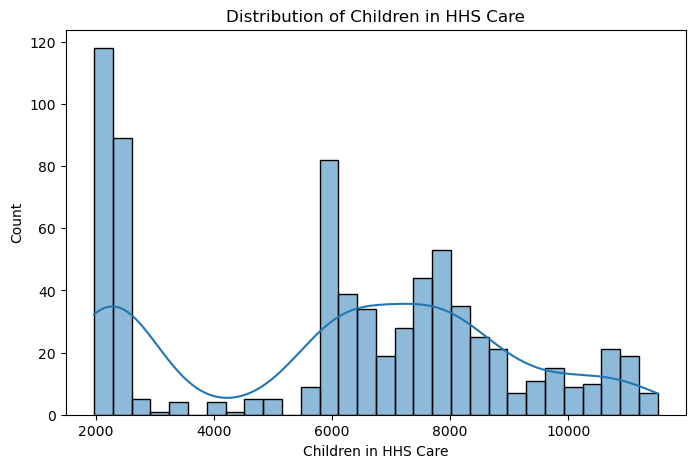

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Children in HHS Care'],
    bins=30,
    kde=True
)

plt.title("Distribution of Children in HHS Care")

plt.show()

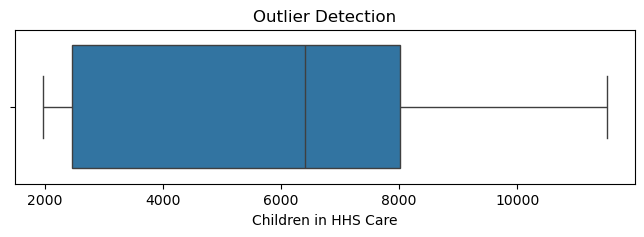

In [42]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df['Children in HHS Care']
)

plt.title("Outlier Detection")

plt.show()

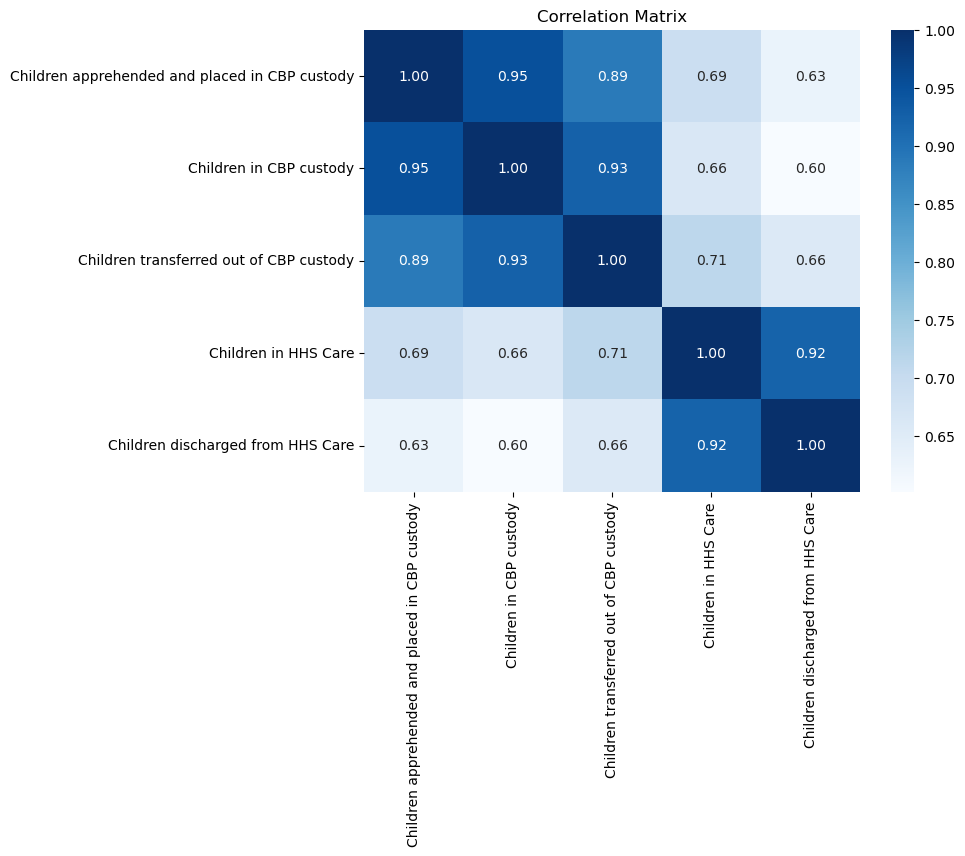

In [43]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [44]:
df['Net Pressure'] = (
    df['Children transferred out of CBP custody']
    -
    df['Children discharged from HHS Care']
)

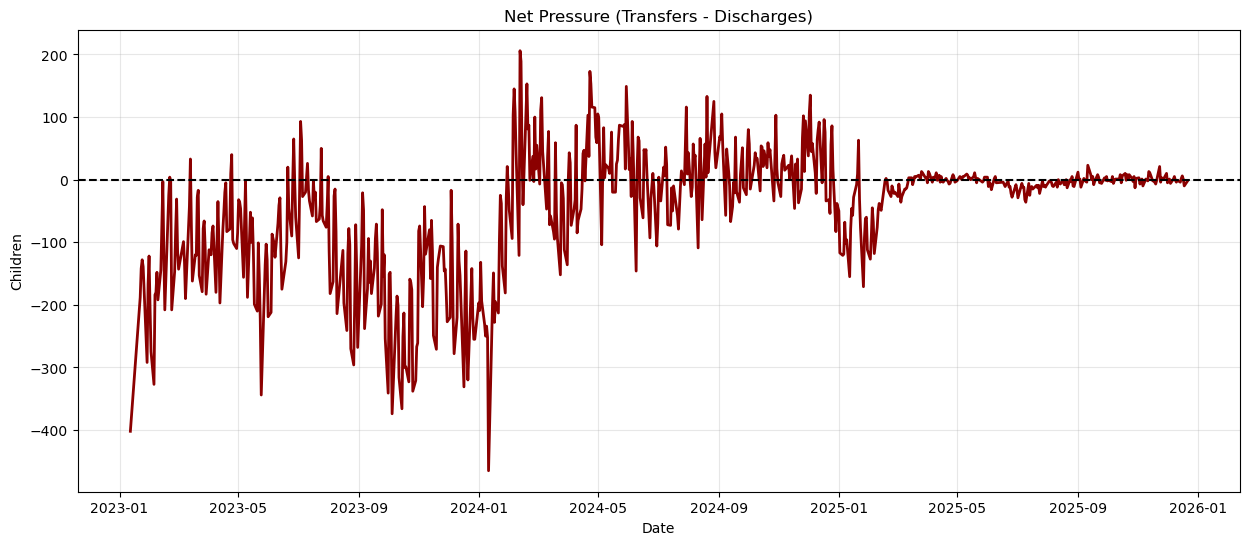

In [45]:
plt.figure(figsize=(15,6))

plt.plot(
    df.index,
    df['Net Pressure'],
    linewidth=2,
    color='darkred'
)

plt.axhline(
    y=0,
    color='black',
    linestyle='--'
)

plt.title("Net Pressure (Transfers - Discharges)")
plt.xlabel("Date")
plt.ylabel("Children")

plt.grid(alpha=0.3)

plt.show()